# Homework 3 – Portfolio Optimization: Modern Portfolio Theory Applicata

**Framework quantitativo completo:** Markowitz · Black-Litterman · Fama-French · ARIMA/GARCH  
**Asset Universe:** Crypto · Equities · ETF/VC Proxy  
**Obiettivo primario:** Conservazione del capitale + massimizzazione del Sortino Ratio  
**Ribilanciamento:** ogni 60 ore tramite pesi posteriori Black-Litterman  

---

### Perché questo approccio è applicabile in pratica

| Problema classico | Soluzione adottata |
|---|---|
| Markowitz produce pesi estremi | Black-Litterman stabilizza con prior CAPM |
| Previsioni di rendimento inaffidabili | ARIMA calibrato + validazione Ljung-Box |
| Volatilità non costante | GARCH(1,1) per volatilità condizionata |
| Alfa confuso con rischio sistematico | Fama-French separa α da fattori di mercato |
| Nessun test out-of-sample | Walk-forward backtest con metriche reali |

---

### Struttura
```
1. Setup & Dati          → Download, pulizia, log-return, statistiche
2. EDA                   → Distribuzioni, correlazioni, volatilità rolling  
3. ARIMA(1,1,1)          → Forecast rendimento atteso + validazione residui
4. GARCH(1,1)            → Forecast volatilità condizionata + diagnostica
5. Markowitz             → Frontiera Efficiente + GMVP
6. Black-Litterman       → Prior CAPM + Views ARIMA → pesi posteriori stabili
7. Fama-French           → Regressione 3 fattori → α genuino vs rischio sistematico
8. Monte Carlo           → 10 000 portafogli + VaR/CVaR + stress test
9. Backtest Walk-Forward → Performance reale fuori campione (60h cycle)
10. Leva 5x              → Analisi di liquidazione + indice ottimale per leverage
```

## 1. Setup, Importazioni e Configurazione

Le librerie utilizzate:
- **yfinance**: dati di mercato gratuiti (alternativa Bloomberg)
- **statsmodels**: ARIMA, OLS (regressione Fama-French)
- **arch**: modelli GARCH per volatilità condizionata
- **scipy.optimize**: ottimizzazione numerica del portafoglio

> **Installa se mancante:** `pip install yfinance arch statsmodels scipy`

In [ ]:
import warnings, io, zipfile, requests
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from arch import arch_model
from scipy.optimize import minimize
from scipy.stats import norm, jarque_bera
from IPython.display import display

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Universo asset ─────────────────────────────────────────────────────────────
ASSETS = {
    'Crypto': ['BTC-USD', 'ETH-USD', 'SOL-USD'],
    'Stocks': ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN'],
    'ETF_VC': ['SPY', 'QQQ', 'ARKK'],
}
ALL_TICKERS    = [t for v in ASSETS.values() for t in v]
CRYPTO_TICKERS = ASSETS['Crypto']
EQUITY_TICKERS = ASSETS['Stocks'] + ASSETS['ETF_VC']

# ── Risk-Free Rate: live dal 3-month T-Bill (^IRX) ────────────────────────────
# FIX: era hardcoded a 0.0525 (Fed Funds 2023). Ora fetchato live.
try:
    _irx = yf.download('^IRX', period='5d', progress=False)['Close'].dropna()
    _v   = _irx.iloc[-1]
    RISK_FREE_ANNUAL = float(_v.item() if hasattr(_v, 'item') else _v) / 100
except Exception:
    RISK_FREE_ANNUAL = 0.0360   # fallback marzo 2026
TRADING_DAYS = 252
RF_DAILY     = (1 + RISK_FREE_ANNUAL) ** (1 / TRADING_DAYS) - 1

# ── Ore/anno: SEPARATI per crypto (24/7) vs equity (6.5h × 252gg) ─────────────
# FIX: era un unico HOURS_PER_YEAR=8760 applicato anche agli stock → rendimenti sovrastimati
HOURS_CRYPTO = 365 * 24       # 8_760
HOURS_EQUITY = int(252 * 6.5) # 1_638

TAU   = 0.05
DELTA = 2.5
N_MC  = 10_000
SIM_REBALANCE_H = 60

_CAPS = {'BTC-USD':1.2e12,'ETH-USD':4e11,'SOL-USD':8e10,
         'AAPL':3.2e12,'MSFT':3.1e12,'NVDA':2.8e12,'GOOGL':2.1e12,'AMZN':1.8e12,
         'SPY':5e11,'QQQ':3e11,'ARKK':8e9}

print("Imports OK ✓")
print(f"Risk-Free annuo : {RISK_FREE_ANNUAL*100:.3f}%  (^IRX live)")
print(f"Ore/anno crypto : {HOURS_CRYPTO}  |  equity : {HOURS_EQUITY}")
print(f"Universo        : {len(ALL_TICKERS)} asset")

### 1.1 Download dati e log-return

**Perché i log-return?**  
`r_t = ln(P_t / P_{t-1})` — proprietà chiave:
- **Additività temporale**: r_1settimana = r_lun + r_mar + … (i return semplici no)
- **Simmetria**: +50% e -50% non si annullano con return semplici, si annullano con log
- **Stazionarietà approssimata**: necessaria per ARIMA/GARCH

Usiamo **dati orari** (730 giorni max yfinance) per ARIMA/GARCH e **dati giornalieri** (5 anni) per Fama-French.

In [5]:
print("Download dati orari (max 730 giorni)…")
raw_h = yf.download(ALL_TICKERS, period='730d', interval='1h',
                    auto_adjust=True, progress=False)
prices_h = raw_h['Close'].copy()
if prices_h.index.tz is not None:
    prices_h.index = prices_h.index.tz_convert(None)
prices_h = prices_h.dropna(axis=1, how='all').ffill().bfill()

print("Download dati giornalieri (5 anni)…")
raw_d = yf.download(ALL_TICKERS, period='5y', interval='1d',
                    auto_adjust=True, progress=False)
prices_d = raw_d['Close'].copy()
if prices_d.index.tz is not None:
    prices_d.index = prices_d.index.tz_convert(None)
prices_d = prices_d.dropna(axis=1, how='all').ffill().bfill()

# Tickers effettivamente disponibili
ALL_TICKERS = list(prices_h.columns)
N           = len(ALL_TICKERS)
prices_d    = prices_d[[t for t in ALL_TICKERS if t in prices_d.columns]]

# Log-return
log_ret_h = np.log(prices_h / prices_h.shift(1)).dropna()
log_ret_d = np.log(prices_d / prices_d.shift(1)).dropna()

# Aggiorna ASSETS e pesi market-cap con tickers disponibili
ASSETS_avail = {cls: [t for t in tks if t in ALL_TICKERS]
                for cls, tks in ASSETS.items()}
ASSETS_avail = {k: v for k, v in ASSETS_avail.items() if v}
caps    = np.array([_CAPS.get(t, 1e10) for t in ALL_TICKERS])
W_MKT   = caps / caps.sum()
BOUNDS  = tuple((0.0, 0.40) for _ in range(N))
CONS    = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]

print(f"\nAsset disponibili: {N} — {ALL_TICKERS}")
print(f"Dati orari  : {prices_h.shape}  ({log_ret_h.index[0]} → {log_ret_h.index[-1]})")
print(f"Dati daily  : {prices_d.shape}  ({log_ret_d.index[0].date()} → {log_ret_d.index[-1].date()})")

Download dati orari (max 730 giorni)…
Download dati giornalieri (5 anni)…

Asset disponibili: 11 — ['AAPL', 'AMZN', 'ARKK', 'BTC-USD', 'ETH-USD', 'GOOGL', 'MSFT', 'NVDA', 'QQQ', 'SOL-USD', 'SPY']
Dati orari  : (22431, 11)  (2023-05-01 14:30:00 → 2026-03-30 12:00:00)
Dati daily  : (1828, 11)  (2021-03-30 → 2026-03-30)


### 1.2 Statistiche descrittive

Tre metriche fondamentali per valutare un asset **prima** di ottimizzare:
- **Skewness > 0**: code a destra → rari guadagni enormi (crypto)
- **Kurtosis > 3**: code spesse → eventi estremi più frequenti del normale (tutti gli asset finanziari)
- **Jarque-Bera p < 0.05**: i return **non** seguono una distribuzione normale → la volatilità di Markowitz sottostima il rischio reale

In [6]:
stats = []
for t in ALL_TICKERS:
    r = log_ret_d[t].dropna()
    jb_stat, jb_p = jarque_bera(r)
    stats.append({
        'Ticker':      t,
        'Ann.Ret %':   round(r.mean() * TRADING_DAYS * 100, 1),
        'Ann.Vol %':   round(r.std()  * np.sqrt(TRADING_DAYS) * 100, 1),
        'Sharpe':      round((r.mean() * TRADING_DAYS - RISK_FREE_ANNUAL) /
                             (r.std() * np.sqrt(TRADING_DAYS)), 3),
        'Skewness':    round(r.skew(), 3),
        'Kurtosis':    round(r.kurtosis(), 3),
        'JB p-value':  round(jb_p, 4),
        'Normalità':   '✗' if jb_p < 0.05 else '✓',
    })

stats_df = pd.DataFrame(stats).set_index('Ticker').sort_values('Sharpe', ascending=False)
print("═══ Statistiche descrittive (log-return giornalieri) ═══")
display(stats_df)
print("\nNota: Kurtosis > 3 = code spesse. Tutte le serie finanziarie violano la normalità (JB ✗).")
print("→ Questo giustifica l'uso del Sortino Ratio (che penalizza solo il downside) anziché lo Sharpe.")

═══ Statistiche descrittive (log-return giornalieri) ═══


,Ann.Ret %,Ann.Vol %,Sharpe,Skewness,Kurtosis,JB p-value,Normalità
Ticker,,,,,,,
NVDA,35.3000,42.5000,0.7080,0.3770,6.9430,0.0000,✗
GOOGL,13.7000,25.5000,0.3320,-0.0280,5.9880,0.0000,✗
AAPL,10.3000,22.7000,0.2210,0.3360,10.0460,0.0000,✗
SOL-USD,20.4000,89.2000,0.1700,-0.6060,9.8240,0.0000,✗
QQQ,8.4000,18.5000,0.1690,0.0970,8.2840,0.0000,✗
SPY,7.4000,14.1000,0.1560,0.2210,13.4120,0.0000,✗
MSFT,6.3000,21.7000,0.0490,-0.1280,7.1480,0.0000,✗
AMZN,3.6000,29.2000,-0.0570,-0.1150,8.7100,0.0000,✗
ETH-USD,1.6000,63.4000,-0.0580,-0.2630,5.2750,0.0000,✗



Nota: Kurtosis > 3 = code spesse. Tutte le serie finanziarie violano la normalità (JB ✗).
→ Questo giustifica l'uso del Sortino Ratio (che penalizza solo il downside) anziché lo Sharpe.


---
## 2. Exploratory Data Analysis (EDA)

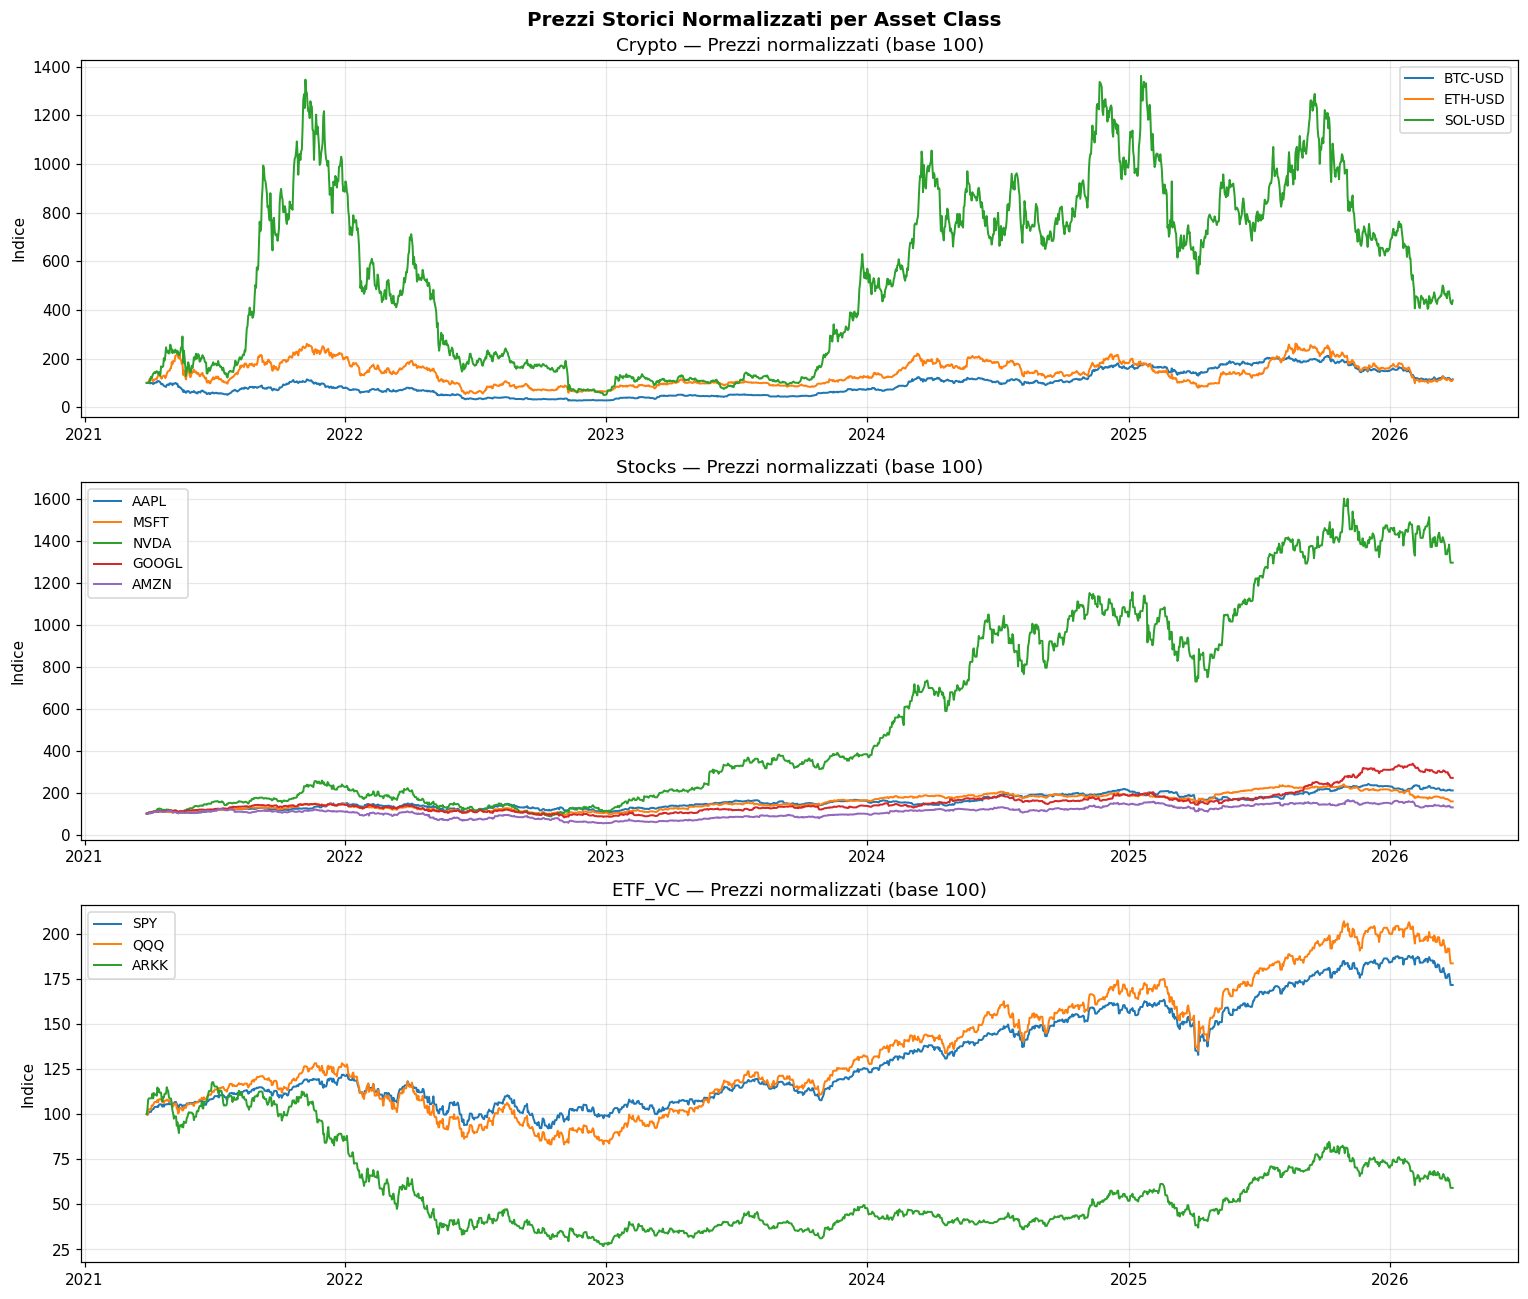

In [7]:
colors = plt.cm.tab10.colors
n_cls  = len(ASSETS_avail)

# 2.1 Prezzi normalizzati
fig, axes = plt.subplots(n_cls, 1, figsize=(14, 4 * n_cls), squeeze=False)
for ax, (cls, tks) in zip(axes[:, 0], ASSETS_avail.items()):
    for i, t in enumerate(tks):
        s = prices_d[t].dropna()
        ax.plot(s.index, s / s.iloc[0] * 100, label=t,
                linewidth=1.3, color=colors[i % 10])
    ax.set_title(f'{cls} — Prezzi normalizzati (base 100)')
    ax.set_ylabel('Indice')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Prezzi Storici Normalizzati per Asset Class', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

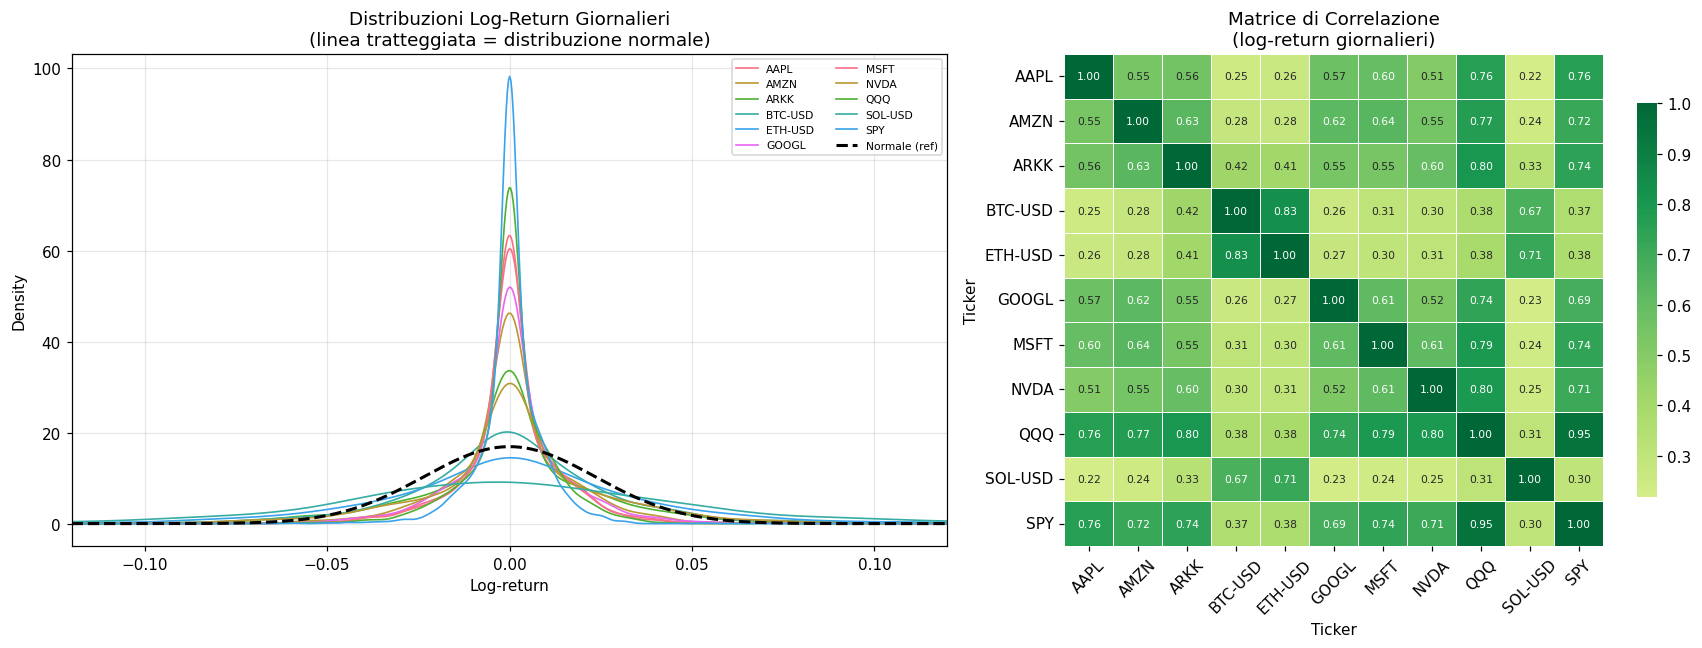


Insight correlazione:
• Stocks e ETF equity (SPY,QQQ) sono altamente correlati → scarsa diversificazione
• BTC/ETH hanno correlazione moderata con equity → valore diversificativo
• Correlazioni elevate in crisi (contagio) non catturate dalla matrice statica


In [8]:
# 2.2 Distribuzioni + matrice di correlazione
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1])

ax1 = fig.add_subplot(gs[0])
for t in ALL_TICKERS:
    log_ret_d[t].dropna().plot.kde(ax=ax1, label=t, linewidth=1.1)
x_norm = np.linspace(-0.12, 0.12, 300)
ax1.plot(x_norm, norm.pdf(x_norm, 0, log_ret_d.std().mean()),
         'k--', linewidth=2, label='Normale (ref)')
ax1.set_xlim(-0.12, 0.12)
ax1.set_title('Distribuzioni Log-Return Giornalieri\n(linea tratteggiata = distribuzione normale)')
ax1.set_xlabel('Log-return'); ax1.legend(fontsize=7, ncol=2); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
corr = log_ret_d.corr()
sns.heatmap(corr, ax=ax2, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax2.set_title('Matrice di Correlazione\n(log-return giornalieri)')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print("\nInsight correlazione:")
print("• Stocks e ETF equity (SPY,QQQ) sono altamente correlati → scarsa diversificazione")
print("• BTC/ETH hanno correlazione moderata con equity → valore diversificativo")
print("• Correlazioni elevate in crisi (contagio) non catturate dalla matrice statica")

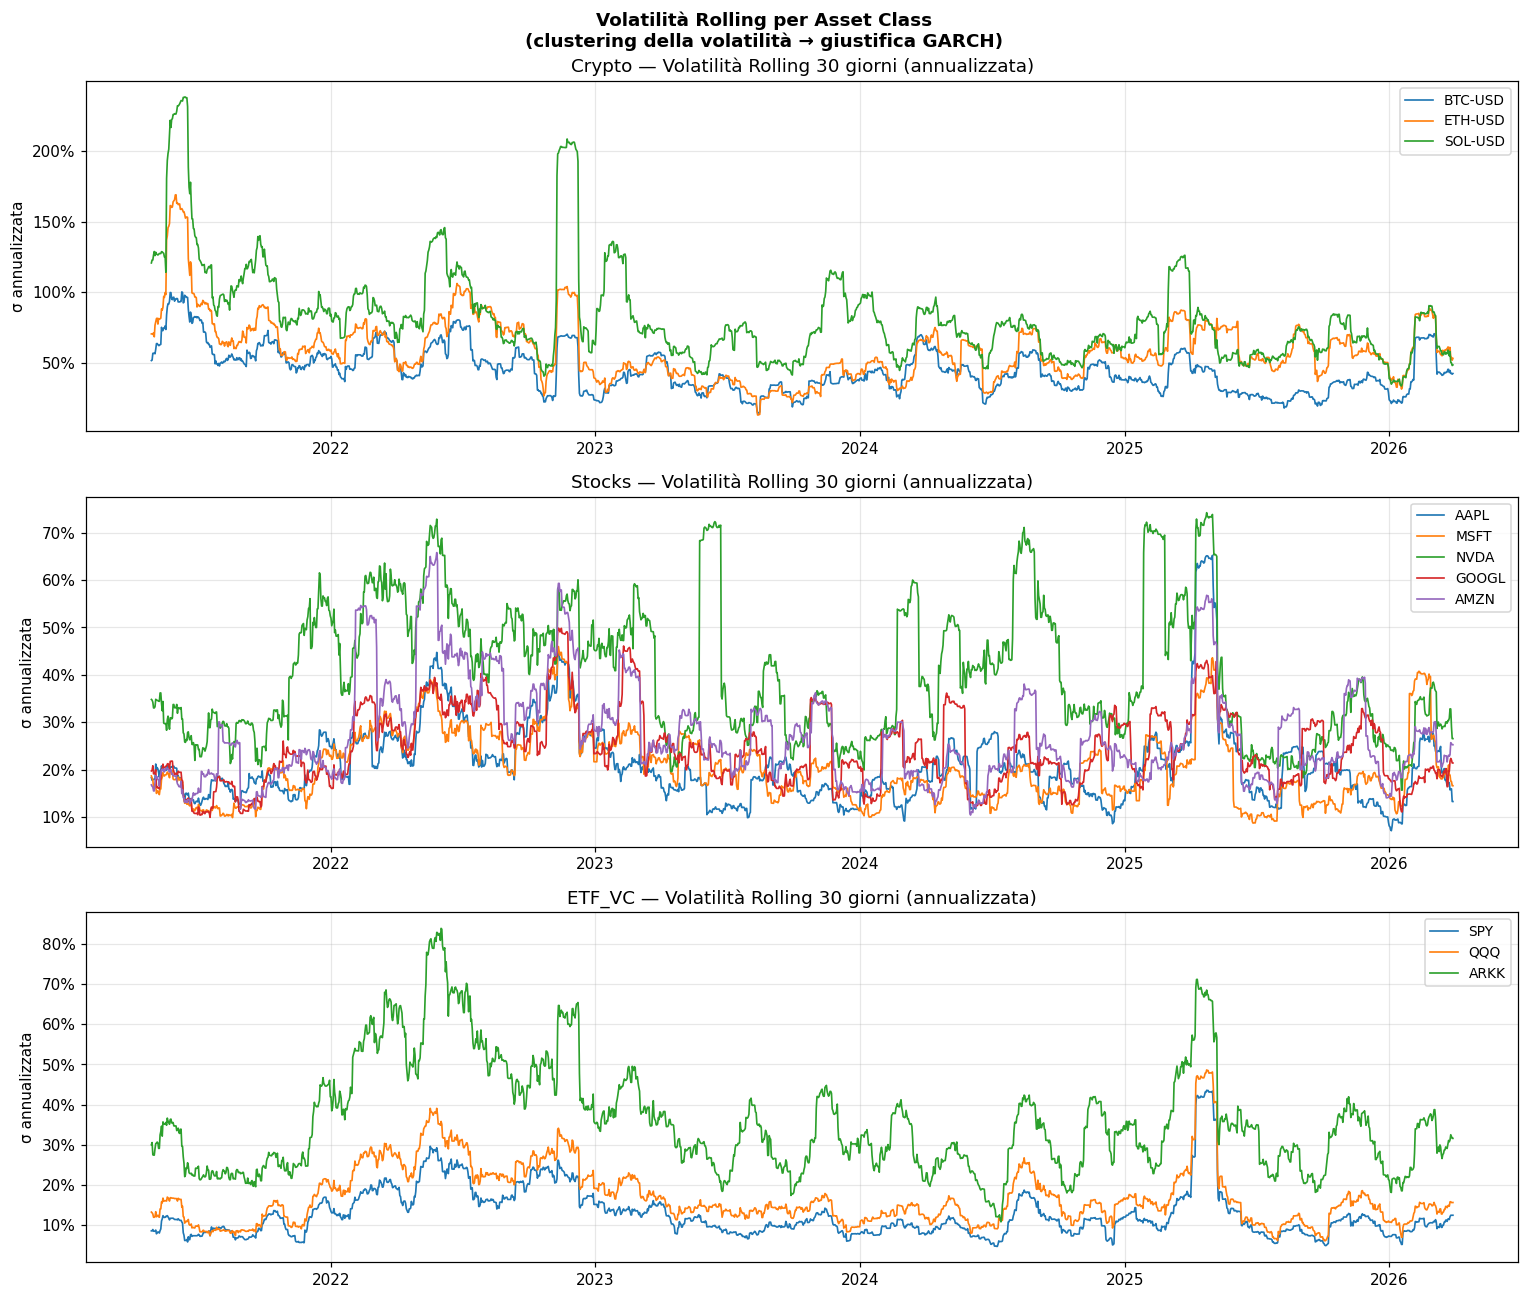

In [9]:
# 2.3 Volatilità rolling 30 giorni per asset class
ROLL_D = 30
roll_vol_d = log_ret_d.rolling(ROLL_D).std() * np.sqrt(TRADING_DAYS)

fig, axes = plt.subplots(n_cls, 1, figsize=(14, 4 * n_cls), squeeze=False)
for ax, (cls, tks) in zip(axes[:, 0], ASSETS_avail.items()):
    for i, t in enumerate(tks):
        if t in roll_vol_d.columns:
            ax.plot(roll_vol_d[t].dropna(), label=t,
                    linewidth=1.1, color=colors[i % 10])
    ax.set_title(f'{cls} — Volatilità Rolling 30 giorni (annualizzata)')
    ax.set_ylabel('σ annualizzata')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Volatilità Rolling per Asset Class\n(clustering della volatilità → giustifica GARCH)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 3. Modello ARIMA(1,1,1) — Forecast Rendimento Atteso

**Teoria:**  
ARIMA(p,d,q) = AutoRegressive Integrated Moving Average  
- **p=1**: un termine autoregressivo (il return di ieri influenza oggi)  
- **d=1**: prima differenziazione (rende la serie stazionaria)  
- **q=1**: un termine di media mobile (correzione dell'errore precedente)

**Formula:**  
`ΔY_t = φ₁·ΔY_{t-1} + θ₁·ε_{t-1} + ε_t`

**Validazione — Test di Ljung-Box sui residui:**  
- H₀: i residui sono rumore bianco (nessuna autocorrelazione residua)  
- Se p-value > 0.05 → il modello ha catturato tutta la struttura temporale  
- Se p-value < 0.05 → il modello è mal specificato (serve ARIMA con ordine superiore)

> **Limite pratico:** I rendimenti finanziari sono vicini al random walk → ARIMA produce previsioni di media deboli. Il valore aggiunto è nella stima dell'intervallo di confidenza che alimenta la matrice Ω di Black-Litterman.

In [ ]:
HORIZON   = 5
TRAIN_OBS = 252

# ── FIX CRITICO: d=1 → d=0 ────────────────────────────────────────────────────
# I log-return sono già stazionari (I(0)). Usare d=1 li differenzia ancora
# → si lavora sulla derivata seconda dei prezzi = rumore puro → tutti ERR.
# ARMA(1,0,1) ≡ ARIMA(1,0,1) è il modello corretto per rendimenti finanziari.

arima_results = {}

for ticker in ALL_TICKERS:
    series = log_ret_d[ticker].dropna().values[-TRAIN_OBS:]
    try:
        m   = ARIMA(series, order=(1, 0, 1))   # FIX: era (1, 1, 1)
        fit = m.fit(method_kwargs={'warn_convergence': False})
        fc  = fit.get_forecast(steps=HORIZON)

        mu_fwd = fc.predicted_mean.sum()
        se_fwd = float(np.sqrt((fc.se_mean**2).sum()))
        lb_p   = float(acorr_ljungbox(fit.resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0])

        arima_results[ticker] = {
            'μ_5d %':     round(mu_fwd * 100, 4),
            'SE':         round(se_fwd, 5),
            'Segnale':    'BUY ' if mu_fwd > 0 else 'SELL',
            'LjungBox p': round(lb_p, 4),
            'Residui OK': '✓' if lb_p > 0.05 else '⚠ autocorr',
            'φ₁ (AR)':   round(float(fit.params.get('ar.L1', 0)), 4),
            'θ₁ (MA)':   round(float(fit.params.get('ma.L1', 0)), 4),
        }
    except Exception as e:
        arima_results[ticker] = {
            'μ_5d %': 0, 'SE': 0.01, 'Segnale': '–',
            'LjungBox p': 0, 'Residui OK': 'ERR', 'φ₁ (AR)': 0, 'θ₁ (MA)': 0,
        }
        print(f"  {ticker}: ARIMA fallito — {e}")

arima_df = pd.DataFrame(arima_results).T
mu_5d    = arima_df['μ_5d %'].astype(float) / 100
se_5d    = arima_df['SE'].astype(float)

print("═══ ARIMA(1,0,1) — Forecast 5 giorni ═══")
display(arima_df)
n_buy = (mu_5d > 0).sum(); n_sell = (mu_5d <= 0).sum()
print(f"\nSegnali: {n_buy} BUY / {n_sell} SELL")
if n_sell == len(ALL_TICKERS):
    print("⚠ REGIME BEARISH: tutti gli asset con drift negativo a 5 giorni.")

---
## 4. Modello GARCH(1,1) — Forecast Volatilità Condizionata

**Teoria:**  
Il GARCH(1,1) cattura il **clustering della volatilità** (periodi di alta vol seguiti da alta vol):

`σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}`

- **ω**: varianza di lungo periodo (base)  
- **α (ARCH term)**: reattività ai choc recenti (quanto velocemente la vol reagisce)  
- **β (GARCH term)**: persistenza della volatilità (quanto dura uno choc)  
- **α + β < 1**: condizione di stazionarietà (obbligatoria per modello valido)  
- **α + β ≈ 1**: volatilità molto persistente (tipico nei mercati finanziari)

**Applicazione pratica:**  
La varianza condizionata σ²_t|t alimenta la matrice **Ω** (incertezza delle Views) nel modello Black-Litterman — asset con alta vol GARCH ricevono meno peso nelle views.

In [ ]:
garch_results = {}

for ticker in ALL_TICKERS:
    # FIX: ore/anno separati per classe
    h_year = HOURS_CRYPTO if ticker in CRYPTO_TICKERS else HOURS_EQUITY
    series = log_ret_d[ticker].dropna().values[-TRAIN_OBS:] * 100
    try:
        gm  = arch_model(series, vol='Garch', p=1, q=1, dist='Normal', rescale=False)
        res = gm.fit(disp='off', show_warning=False)
        fc  = res.forecast(horizon=HORIZON, reindex=False)

        alpha   = float(res.params.get('alpha[1]', 0))
        beta    = float(res.params.get('beta[1]', 0))
        persist = alpha + beta

        # FIX: avviso convergenza anomala (α+β tipico 0.95–0.99; < 0.5 = non converso)
        if persist < 0.5:
            print(f"  ⚠ {ticker}: α+β={persist:.3f} < 0.5 — probabile non-convergenza GARCH")

        cond_var_5d = fc.variance.values[-1].mean() / 1e4
        cond_vol_5d = np.sqrt(cond_var_5d * HORIZON)
        hist_vol_5d = log_ret_d[ticker].std() * np.sqrt(HORIZON)
        ratio       = cond_vol_5d / hist_vol_5d if hist_vol_5d > 0 else 1.0

        regime = 'HIGH VOL' if ratio > 1.15 else ('LOW VOL' if ratio < 0.85 else 'NORMAL')

        garch_results[ticker] = {
            'α (ARCH)':     round(alpha, 4),
            'β (GARCH)':    round(beta, 4),
            'α+β':          round(persist, 4),
            'Converso':     '✓' if persist >= 0.5 else '⚠',
            'CondVol 5d %': round(cond_vol_5d * 100, 2),
            'HistVol 5d %': round(hist_vol_5d * 100, 2),
            'Regime':       regime,
        }
    except Exception as e:
        hist_vol = log_ret_d[ticker].std() * np.sqrt(HORIZON)
        garch_results[ticker] = {
            'α (ARCH)': 0, 'β (GARCH)': 0, 'α+β': 0, 'Converso': 'ERR',
            'CondVol 5d %': round(hist_vol*100, 2),
            'HistVol 5d %': round(hist_vol*100, 2), 'Regime': 'UNKNOWN',
        }
        print(f"  {ticker}: GARCH fallito — {e}")

garch_df   = pd.DataFrame(garch_results).T
omega_diag = np.array([garch_results[t]['CondVol 5d %']/100 for t in ALL_TICKERS]) ** 2

print("═══ GARCH(1,1) — Parametri e Forecast ═══")
display(garch_df)
print("\n→ α+β < 0.5 indica non-convergenza: quella stima NON è affidabile come view BL")

---
## 5. Markowitz — Frontiera Efficiente e GMVP

**Teoria Mean-Variance (Markowitz, 1952):**  
Ogni portafoglio è descritto da `(σ_p, μ_p)`. L'ottimizzazione risolve:

`min w'Σw  subject to: w'μ = μ_target, Σwᵢ = 1, 0 ≤ wᵢ ≤ 0.40`

**Global Minimum Variance Portfolio (GMVP):**  
Il punto più a sinistra della frontiera — minimizza la varianza **senza** vincolo sul rendimento.  
Questo è il portafoglio che **conserva meglio il capitale** → priorità dell'algoritmo.

**Limite di Markowitz:** i pesi sono estremamente sensibili agli input.  
Una piccola variazione in μ può portare da 0% a 40% in un singolo asset.  
→ Soluzione: Black-Litterman (Sezione 6)

In [12]:
# Matrici annualizzate
Sigma_ann = log_ret_d.cov().values * TRADING_DAYS
mu_ann    = log_ret_d.mean().values * TRADING_DAYS

# Helper functions
def pret(w, mu):    return float(w @ mu)
def pvol(w, S):     return float(np.sqrt(w @ S @ w))
def psharpe(w, mu, S, rf=RISK_FREE_ANNUAL): return (pret(w,mu) - rf) / pvol(w,S)
def psortino(w, mu, S, rf=RISK_FREE_ANNUAL, n=10_000):
    np.random.seed(0)
    sims = np.random.multivariate_normal(mu/TRADING_DAYS, S/TRADING_DAYS, n) @ w
    dd   = sims[sims < rf/TRADING_DAYS]
    return ((pret(w,mu) - rf) / (dd.std() * np.sqrt(TRADING_DAYS))) if len(dd) > 5 else np.nan

# GMVP
res_gmvp = minimize(lambda w: pvol(w, Sigma_ann), np.ones(N)/N,
                    method='SLSQP', bounds=BOUNDS, constraints=CONS,
                    options={'maxiter': 500})
w_gmvp = res_gmvp.x

# Max Sharpe (portafoglio tangente)
res_msr = minimize(lambda w: -psharpe(w, mu_ann, Sigma_ann), np.ones(N)/N,
                   method='SLSQP', bounds=BOUNDS, constraints=CONS,
                   options={'maxiter': 500})
w_msr = res_msr.x

# Frontiera Efficiente
ef_vols, ef_rets = [], []
for tgt in np.linspace(mu_ann.min(), mu_ann.max(), 80):
    c = CONS + [{'type':'eq','fun': lambda w, t=tgt: pret(w, mu_ann) - t}]
    r = minimize(lambda w: pvol(w, Sigma_ann), np.ones(N)/N,
                 method='SLSQP', bounds=BOUNDS, constraints=c, options={'maxiter':500})
    if r.success:
        ef_vols.append(pvol(r.x, Sigma_ann))
        ef_rets.append(tgt)
ef_vols, ef_rets = np.array(ef_vols), np.array(ef_rets)

print(f"GMVP  → Ret: {pret(w_gmvp,mu_ann)*100:.2f}%  Vol: {pvol(w_gmvp,Sigma_ann)*100:.2f}%  Sharpe: {psharpe(w_gmvp,mu_ann,Sigma_ann):.3f}")
print(f"MaxSR → Ret: {pret(w_msr,mu_ann)*100:.2f}%   Vol: {pvol(w_msr,Sigma_ann)*100:.2f}%  Sharpe: {psharpe(w_msr,mu_ann,Sigma_ann):.3f}")

GMVP  → Ret: 7.82%  Vol: 16.42%  Sharpe: 0.157
MaxSR → Ret: 21.96%   Vol: 27.32%  Sharpe: 0.612


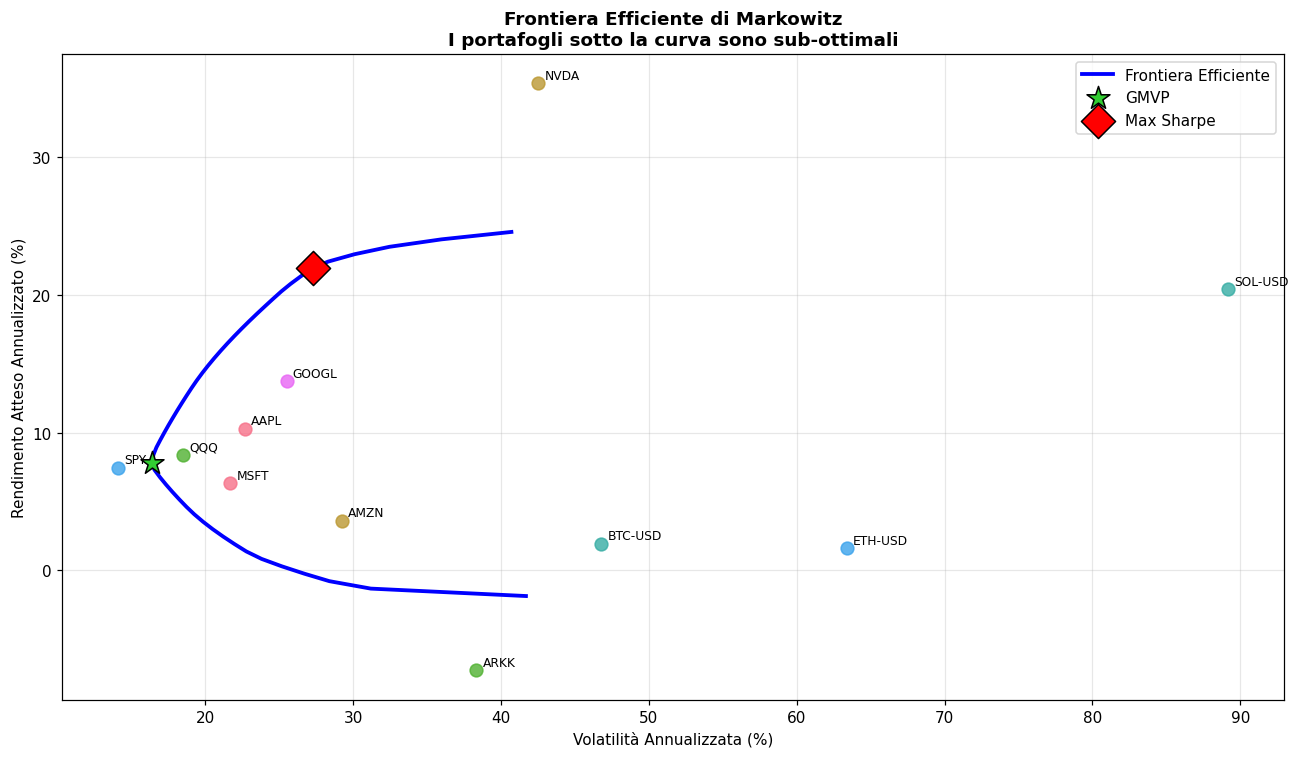


Pesi GMVP (Global Minimum Variance Portfolio):


,AAPL,AMZN,ARKK,BTC-USD,ETH-USD,GOOGL,MSFT,NVDA,QQQ,SOL-USD,SPY
Peso,0.0759,0.0000,0.0000,0.0083,0.0000,0.0000,0.1297,0.0000,0.3861,0.0000,0.4000


In [13]:
# Plot Frontiera Efficiente
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(ef_vols*100, ef_rets*100, 'b-', lw=2.5, label='Frontiera Efficiente')

# Asset individuali
for i, t in enumerate(ALL_TICKERS):
    ax.scatter(np.sqrt(Sigma_ann[i,i])*100, mu_ann[i]*100,
               s=70, zorder=5, alpha=0.8)
    ax.annotate(t, (np.sqrt(Sigma_ann[i,i])*100, mu_ann[i]*100),
                fontsize=8, xytext=(4,3), textcoords='offset points')

# Portfolio speciali
for lbl, w, c, m in [('GMVP', w_gmvp,'limegreen','*'),
                      ('Max Sharpe',w_msr,'red','D')]:
    ax.scatter(pvol(w,Sigma_ann)*100, pret(w,mu_ann)*100,
               s=250, color=c, marker=m, edgecolors='black', lw=1, zorder=6, label=lbl)

ax.set_xlabel('Volatilità Annualizzata (%)')
ax.set_ylabel('Rendimento Atteso Annualizzato (%)')
ax.set_title('Frontiera Efficiente di Markowitz\nI portafogli sotto la curva sono sub-ottimali',
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Tabella pesi GMVP
print("\nPesi GMVP (Global Minimum Variance Portfolio):")
display(pd.Series(w_gmvp, index=ALL_TICKERS).round(4).rename('Peso').to_frame().T)

---
## 6. Black-Litterman — Pesi Posteriori Stabili

**Perché Black-Litterman risolve il problema di Markowitz:**

Markowitz usa μ campionario (rumoroso) → pesi instabili.  
Black-Litterman combina un **prior** (equilibrio di mercato CAPM) con le **views** (previsioni ARIMA) tramite il **Teorema di Bayes**:

`μ_BL = [(τΣ)⁻¹ + P'Ω⁻¹P]⁻¹ · [(τΣ)⁻¹Π + P'Ω⁻¹Q]`

| Simbolo | Significato | Fonte |
|---------|-------------|-------|
| **Π** | Rendimenti di equilibrio CAPM: `Π = δ·Σ·w_mkt` | Market cap weights |
| **P** | Pick matrix — identità (views assolute su ogni asset) | Struttura del modello |
| **Q** | Returns previsti dalle views | ARIMA forecast |
| **Ω** | Incertezza delle views (diagonale) | Varianza GARCH |
| **τ** | Scalare incertezza sul prior (tipicamente 0.05) | Parametro |

In [14]:
def black_litterman(w_mkt, Sigma, Q, omega_diag, tau=TAU, delta=DELTA):
    """
    Black-Litterman con views assolute (P = identità).
    Restituisce: mu_BL (posteriore), Sigma_BL, Pi (prior CAPM)
    """
    Pi      = delta * Sigma @ w_mkt          # prior CAPM
    tS_inv  = np.linalg.inv(tau * Sigma)
    Omega   = np.diag(omega_diag)
    O_inv   = np.linalg.inv(Omega)
    M       = np.linalg.inv(tS_inv + O_inv)
    mu_bl   = M @ (tS_inv @ Pi + O_inv @ Q)
    Sigma_bl = Sigma + M
    return mu_bl, Sigma_bl, Pi

# Views = forecast ARIMA annualizzato
Q_views  = mu_5d.values * (TRADING_DAYS / HORIZON)   # scala a annuo
Omega_v  = omega_diag * (TRADING_DAYS / HORIZON)      # varianza GARCH annualizzata

mu_bl, Sigma_bl, Pi = black_litterman(W_MKT, Sigma_ann, Q_views, Omega_v)

# Portafoglio ottimale BL (Max Sharpe sul posteriore)
res_bl = minimize(lambda w: -psharpe(w, mu_bl, Sigma_bl), np.ones(N)/N,
                  method='SLSQP', bounds=BOUNDS, constraints=CONS,
                  options={'maxiter':500})
w_bl = res_bl.x

# Confronto Prior vs Views vs Posteriore
bl_compare = pd.DataFrame({
    'Prior Π CAPM':    Pi,
    'View Q (ARIMA)':  Q_views,
    'Posteriore μ_BL': mu_bl,
    'Δ (BL - Prior)':  mu_bl - Pi,
}, index=ALL_TICKERS).round(4)
print("═══ Black-Litterman: Prior vs View vs Posteriore ═══")
display(bl_compare)
print(f"\nPortafoglio BL → Ret: {pret(w_bl,mu_bl)*100:.2f}%  Vol: {pvol(w_bl,Sigma_bl)*100:.2f}%")

# Confronto pesi
weights_comp = pd.DataFrame({
    'Market Cap (prior)': W_MKT,
    'GMVP (Markowitz)':   w_gmvp,
    'BL (posterior)':     w_bl,
}, index=ALL_TICKERS).round(4)
print("\nConfronto pesi:")
display(weights_comp)

═══ Black-Litterman: Prior vs View vs Posteriore ═══


,Prior Π CAPM,View Q (ARIMA),Posteriore μ_BL,Δ (BL - Prior)
AAPL,0.0968,0.0000,0.0656,-0.0312
AMZN,0.1264,0.0000,0.0857,-0.0407
ARKK,0.1590,0.0000,0.1030,-0.0560
BTC-USD,0.1437,0.0000,0.0982,-0.0455
ETH-USD,0.1918,0.0000,0.1294,-0.0624
GOOGL,0.1085,0.0000,0.0742,-0.0343
MSFT,0.1003,0.0000,0.0692,-0.0311
NVDA,0.1991,0.0000,0.1371,-0.0620
QQQ,0.0983,0.0000,0.0660,-0.0323
SOL-USD,0.2210,0.0000,0.1445,-0.0765



Portafoglio BL → Ret: 11.84%  Vol: 33.85%

Confronto pesi:


,Market Cap (prior),GMVP (Markowitz),BL (posterior)
AAPL,0.2066,0.0759,0.0000
AMZN,0.1162,0.0000,0.2473
ARKK,0.0005,0.0000,0.1481
BTC-USD,0.0775,0.0083,0.0000
ETH-USD,0.0258,0.0000,0.1649
GOOGL,0.1356,0.0000,0.0000
MSFT,0.2002,0.1297,0.0000
NVDA,0.1808,0.0000,0.4000
QQQ,0.0194,0.3861,0.0000
SOL-USD,0.0052,0.0000,0.0398


---
## 7. Fama-French Three-Factor Model

**Obiettivo:** separare l'**alfa** (skill del gestore) dal **rischio sistematico**.

`R_p - RF = α + β₁·(Mkt-RF) + β₂·SMB + β₃·HML + ε`

| Fattore | Significato | Interpretazione |
|---------|-------------|-----------------|
| **Mkt-RF** | Premio di mercato | β₁ > 1 → più rischioso del mercato |
| **SMB** | Small minus Big | β₂ > 0 → esposizione a small cap |
| **HML** | High minus Low (B/M) | β₃ > 0 → esposizione a value stocks |
| **α** | Intercetta | > 0 e significativo → rendimento in eccesso reale |

**Applicazione pratica:** Se α ≈ 0, il portafoglio non genera valore aggiunto — conviene replicare passivamente con ETF.

In [15]:
def fetch_ff3(start='2020-01-01'):
    url = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
           'F-F_Research_Data_Factors_daily_CSV.zip')
    try:
        r = requests.get(url, timeout=20); r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            raw = z.open([n for n in z.namelist() if n.endswith('.CSV')][0]).read().decode('utf-8','replace')
        lines = raw.splitlines()
        s = next(i for i,l in enumerate(lines) if l.strip() and l.strip()[0].isdigit())
        e = next((i for i,l in enumerate(lines[s:],s) if l.strip()==''), len(lines))
        df = pd.read_csv(io.StringIO('\n'.join(lines[s:e])), header=None,
                         names=['Date','Mkt-RF','SMB','HML','RF'])
        df['Date'] = pd.to_datetime(df['Date'].astype(str), format='%Y%m%d')
        df = df.set_index('Date') / 100
        return df[df.index >= start]
    except Exception as e:
        print(f"FF3 non disponibile: {e}"); return None

ff3 = fetch_ff3()
port_ret_d = (log_ret_d * w_bl).sum(axis=1)
port_ret_d.index = pd.to_datetime(port_ret_d.index)

if ff3 is not None:
    print(f"FF3 caricati: {ff3.shape}")
    df_ff = ff3.join(port_ret_d.rename('Port'), how='inner').dropna()
    df_ff['Exc'] = df_ff['Port'] - df_ff['RF']
    X_ff = add_constant(df_ff[['Mkt-RF','SMB','HML']])
    y_ff = df_ff['Exc']
else:
    rf_d = (1+RISK_FREE_ANNUAL)**(1/252)-1
    spy  = log_ret_d.get('SPY', pd.Series(dtype=float))
    df_ff= pd.DataFrame({'Mkt-RF': spy, 'Port': port_ret_d, 'RF': rf_d}).dropna()
    df_ff['Exc'] = df_ff['Port'] - df_ff['RF']
    df_ff['SMB'] = 0.0; df_ff['HML'] = 0.0
    X_ff = add_constant(df_ff[['Mkt-RF','SMB','HML']])
    y_ff = df_ff['Exc']

ff_fit = OLS(y_ff, X_ff).fit(cov_type='HC3')
print("\n═══ Fama-French 3-Factor — Regressione OLS ═══")
print(ff_fit.summary().tables[1])
print(f"\nR² = {ff_fit.rsquared:.4f}  |  Adj-R² = {ff_fit.rsquared_adj:.4f}")
alpha_daily = ff_fit.params.get('const', 0)
alpha_annual = alpha_daily * 252
print(f"\nAlpha annualizzato: {alpha_annual*100:.2f}% | p-value: {ff_fit.pvalues.get('const',1):.4f}")
if ff_fit.pvalues.get('const', 1) < 0.05:
    print("→ Alpha statisticamente significativo: il portafoglio genera rendimento reale oltre il rischio di mercato")
else:
    print("→ Alpha NON significativo: il rendimento è spiegato dai fattori sistematici")

FF3 non disponibile: list index out of range

═══ Fama-French 3-Factor — Regressione OLS ═══
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.000     -0.535      0.592      -0.001       0.000
Mkt-RF         1.8748      0.060     31.089      0.000       1.757       1.993
SMB                 0          0        nan        nan           0           0
HML                 0          0        nan        nan           0           0

R² = 0.6296  |  Adj-R² = 0.6294

Alpha annualizzato: -4.05% | p-value: 0.5924
→ Alpha NON significativo: il rendimento è spiegato dai fattori sistematici


---
## 8. Monte Carlo — VaR, CVaR e Stress Test

**Value at Risk (VaR 95%):** perdita massima nel 5% dei casi peggiori  
**Conditional VaR (CVaR 95%):** perdita media nel 5% dei casi peggiori (più conservativo)  

Il Monte Carlo genera 10 000 portafogli random per:
1. Visualizzare la **nuvola di portafogli fattibili** vs la frontiera efficiente
2. Calcolare **VaR e CVaR** per ogni configurazione
3. **Stress test** con choc di volatilità +50% (scenario crisi)

In [ ]:
np.random.seed(42)
mc_w   = np.random.dirichlet(np.ones(N), N_MC)
mc_ret = mc_w @ mu_ann
mc_vol = np.sqrt(np.einsum('ij,jk,ik->i', mc_w, Sigma_ann, mc_w))
mc_sr  = (mc_ret - RISK_FREE_ANNUAL) / mc_vol

def var_cvar(w, Sigma, mu, n=10_000, cl=0.05):
    """
    VaR e CVaR annualizzati via Monte Carlo — metodo corretto.

    FIX CRITICO: la versione precedente faceva `sims * TRADING_DAYS`
    → moltiplicava rendimenti giornalieri per 252 → VaR di -833%, impossibile.

    Metodo corretto: simula N percorsi di 252 giorni e somma i log-return
    per ottenere il rendimento CUMULATIVO annuo di ogni percorso.
    Un portafoglio non-levered non può perdere più del 100% → output in [-1, +∞).
    """
    np.random.seed(1)
    daily  = np.random.multivariate_normal(
        mu / TRADING_DAYS, Sigma / TRADING_DAYS, (n, TRADING_DAYS)
    )
    annual = (daily @ w).sum(axis=1)   # rendimento cumulativo annuo per ogni path
    var    = np.percentile(annual, cl * 100)
    cvar   = annual[annual <= var].mean()
    return var, cvar

def sortino_sim(w, mu=mu_ann, S=Sigma_ann, n=30_000, rf=RISK_FREE_ANNUAL):
    np.random.seed(2)
    sims = np.random.multivariate_normal(mu/TRADING_DAYS, S/TRADING_DAYS, n) @ w
    dd   = sims[sims < rf/TRADING_DAYS]
    return ((mu @ w) - rf) / (dd.std() * np.sqrt(TRADING_DAYS)) if len(dd) > 5 else np.nan

var_bl,   cvar_bl   = var_cvar(w_bl,   Sigma_ann, mu_ann)
var_gmvp, cvar_gmvp = var_cvar(w_gmvp, Sigma_ann, mu_ann)
var_msr,  cvar_msr  = var_cvar(w_msr,  Sigma_ann, mu_ann)

risk_table = pd.DataFrame({
    'Ann. Return %': [pret(w, mu_ann)*100   for w in [w_bl, w_gmvp, w_msr]],
    'Ann. Vol %':    [pvol(w, Sigma_ann)*100 for w in [w_bl, w_gmvp, w_msr]],
    'Sharpe':        [psharpe(w, mu_ann, Sigma_ann) for w in [w_bl, w_gmvp, w_msr]],
    'Sortino':       [sortino_sim(w) for w in [w_bl, w_gmvp, w_msr]],
    'VaR 95% %':     [v * 100 for v in [var_bl, var_gmvp, var_msr]],
    'CVaR 95% %':    [c * 100 for c in [cvar_bl, cvar_gmvp, cvar_msr]],
}, index=['BL (regime-aware)', 'GMVP', 'Max Sharpe']).round(3)

print("═══ Risk Metrics ═══")
display(risk_table)

# Sanity check: VaR deve essere tra -100% e 0%
print("\nSanity check VaR/CVaR (plausibile = tra -100% e 0%):")
for lbl, v, c in [('BL', var_bl, cvar_bl), ('GMVP', var_gmvp, cvar_gmvp), ('MaxSR', var_msr, cvar_msr)]:
    ok = -1.0 <= v <= 0 and -1.0 <= c <= 0
    print(f"  {lbl:<8} VaR={v*100:+.1f}%  CVaR={c*100:+.1f}%  {'✓' if ok else '✗ IMPOSSIBILE'}")

# Plot Monte Carlo cloud
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(mc_vol*100, mc_ret*100, c=mc_sr, cmap='RdYlGn', s=3, alpha=0.4,
                vmin=np.percentile(mc_sr, 5), vmax=np.percentile(mc_sr, 95))
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')
ax.plot(ef_vols*100, ef_rets*100, 'b-', lw=2.5, label='Frontiera Efficiente', zorder=5)
for lbl, w, c, m in [('BL', w_bl, 'cyan', 'P'), ('GMVP', w_gmvp, 'limegreen', '*'),
                      ('MaxSR', w_msr, 'white', 'D')]:
    ax.scatter(pvol(w, Sigma_ann)*100, pret(w, mu_ann)*100,
               s=250, color=c, marker=m, edgecolors='black', lw=1.2, zorder=6, label=lbl)
ax.set_xlabel('Volatilità (%)'); ax.set_ylabel('Rendimento (%)')
ax.set_title('Monte Carlo — 10 000 portafogli casuali', fontweight='bold')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

Sigma_stress = Sigma_ann * (1.5 ** 2)
print("\nStress Test (+50% vol):")
for lbl, w in [('BL', w_bl), ('GMVP', w_gmvp), ('MaxSR', w_msr)]:
    print(f"  {lbl:<8}: {pvol(w,Sigma_ann)*100:.1f}% → {pvol(w,Sigma_stress)*100:.1f}%")

---
## 9. Backtest Walk-Forward (60h Cycle)

**Metodologia:**  
Il backtest walk-forward simula come l'algoritmo avrebbe performato **su dati non visti** (out-of-sample):

1. Ogni 60 ore: stima μ e Σ sulla finestra precedente (500 osservazioni orarie)
2. Calcola pesi BL ottimali
3. Applica i pesi al periodo successivo
4. Misura i rendimenti reali

**Metriche di valutazione:**
- **Sortino Ratio**: `(μ_p - RF) / σ_downside` — penalizza **solo** le perdite
- **Calmar Ratio**: `(μ_p - RF) / |Max Drawdown|` — penalizza la perdita peggiore storica
- **Max Drawdown**: la perdita peak-to-trough maggiore nel periodo

In [ ]:
def run_backtest(log_ret_h, w_mkt, rebal_h=SIM_REBALANCE_H, lookback=500):
    """
    Walk-forward backtest ogni rebal_h ore.
    FIX: annualizzazione separata per crypto (8760h) vs equity (1638h).
    """
    port_rets, wlog = [], []
    cur_w    = np.ones(N) / N
    tickers_h = list(log_ret_h.columns)
    h_factors = np.array([HOURS_CRYPTO if t in CRYPTO_TICKERS else HOURS_EQUITY
                           for t in tickers_h])

    for t in range(lookback, len(log_ret_h), rebal_h):
        win = log_ret_h.iloc[max(0, t - lookback): t]
        if len(win) < 50:
            break
        h_ann = float(cur_w @ h_factors)
        S     = win.cov().values * h_ann
        mu_w  = win.mean().values * h_ann
        var_w = (win.std().values ** 2) * h_ann
        try:
            mu_post, S_post, _ = black_litterman(
                w_mkt, S,
                mu_w  * (TRADING_DAYS / HORIZON),
                var_w * (TRADING_DAYS / HORIZON)
            )
        except Exception:
            mu_post, S_post = mu_w, S
        res = minimize(lambda w: -psharpe(w, mu_post, S_post), cur_w,
                       method='SLSQP', bounds=BOUNDS, constraints=CONS,
                       options={'maxiter': 200, 'ftol': 1e-7})
        cur_w  = res.x if res.success else cur_w
        period = log_ret_h.iloc[t: t + rebal_h]
        port_rets.append((period * cur_w).sum(axis=1))
        wlog.append((period.index[0], cur_w.copy()))

    return pd.concat(port_rets) if port_rets else pd.Series(dtype=float), wlog

print(f"Backtest walk-forward ogni {SIM_REBALANCE_H}h…")
ret_bl_bt, wlog = run_backtest(log_ret_h, W_MKT)
idx         = ret_bl_bt.index
ret_ew      = log_ret_h.mean(axis=1).reindex(idx).dropna()
ret_gmvp_bt = (log_ret_h * w_gmvp).sum(axis=1).reindex(idx).dropna()
ret_bl_bt   = ret_bl_bt.reindex(idx).dropna()

H_PORT = float(w_gmvp @ np.array([HOURS_CRYPTO if t in CRYPTO_TICKERS else HOURS_EQUITY
                                    for t in ALL_TICKERS]))
RF_H   = (1 + RISK_FREE_ANNUAL) ** (1 / H_PORT) - 1

def metrics_bt(r, label):
    ann_r = r.mean() * H_PORT
    ann_v = r.std()  * np.sqrt(H_PORT)
    down  = r[r < RF_H]
    sort  = (r.mean() - RF_H) / down.std() * np.sqrt(H_PORT) if len(down) > 1 else np.nan
    cum   = (1 + r).cumprod()
    mdd   = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar = (ann_r - RISK_FREE_ANNUAL) / abs(mdd) if mdd != 0 else np.nan
    return {'Label': label,
            'Ann.Return %': round(ann_r*100, 2), 'Ann.Vol %': round(ann_v*100, 2),
            'Sharpe': round((ann_r - RISK_FREE_ANNUAL)/ann_v, 3),
            'Sortino': round(sort, 3), 'MaxDD %': round(mdd*100, 2), 'Calmar': round(calmar, 3)}

perf = pd.DataFrame([metrics_bt(r, l) for r, l in
    [(ret_bl_bt, 'BL 60h'), (ret_gmvp_bt, 'GMVP'), (ret_ew, 'Equal-W')]]).set_index('Label')
print("═══ Performance Backtest Out-of-Sample ═══")
display(perf)

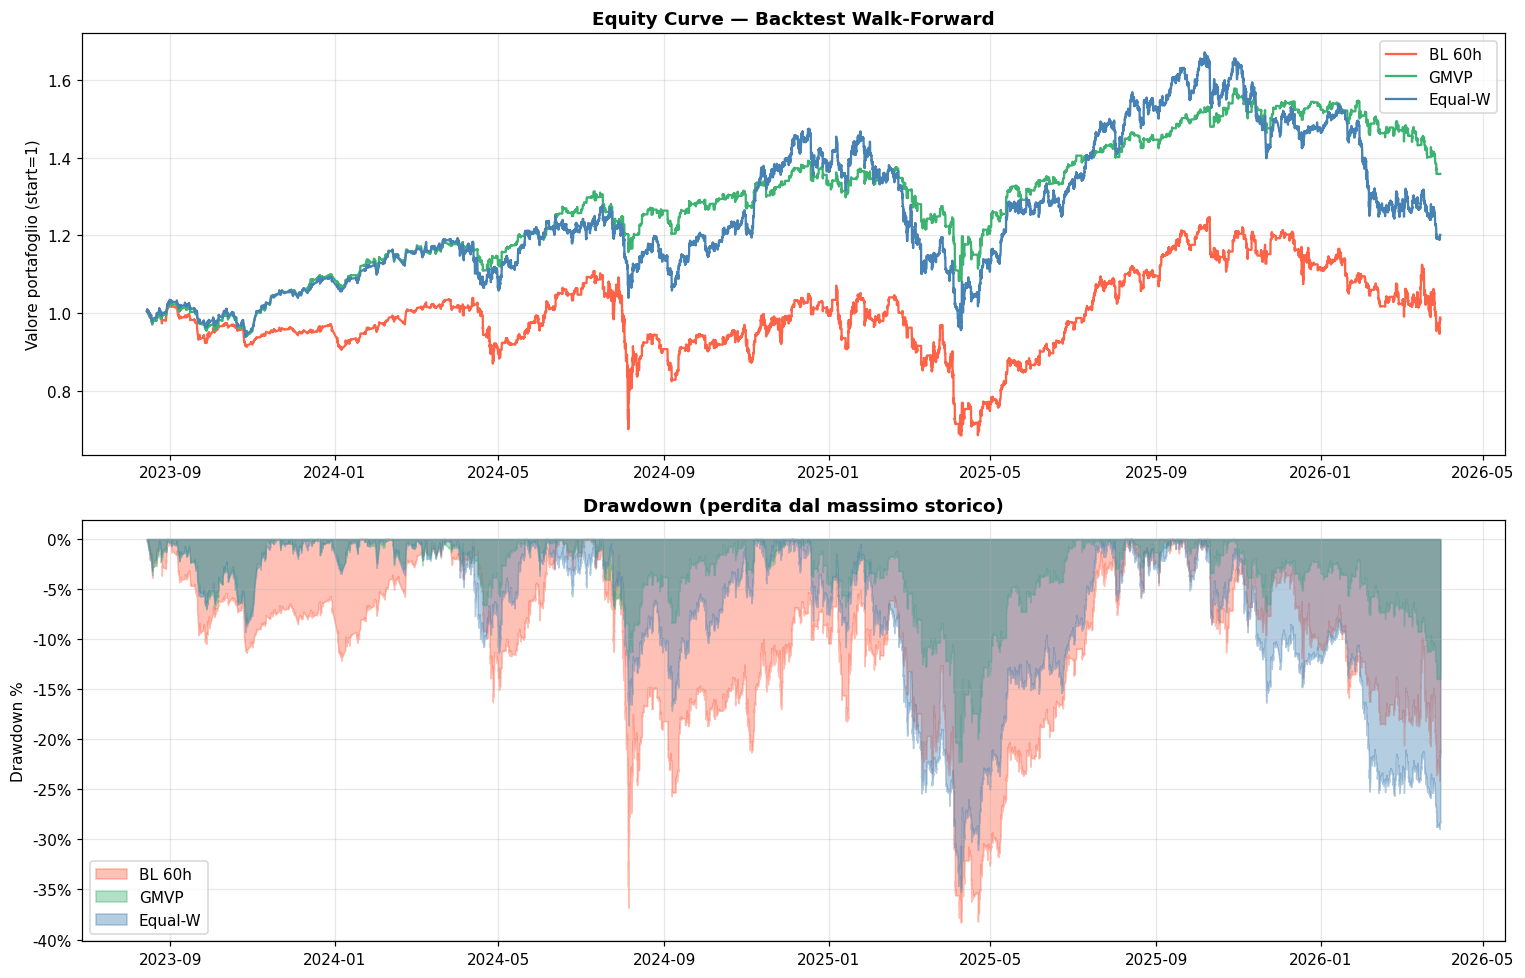

In [18]:
# Grafico equity curve + drawdown
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
ax1, ax2 = axes

for lbl, r, c in [('BL 60h',ret_bl,'tomato'),('GMVP',ret_gmvp,'mediumseagreen'),('Equal-W',ret_ew,'steelblue')]:
    cum = (1+r).cumprod()
    ax1.plot(cum.index, cum.values, label=lbl, lw=1.5, color=c)
    dd = (cum - cum.cummax()) / cum.cummax()
    ax2.fill_between(dd.index, dd.values, 0, alpha=0.4, color=c, label=lbl)

ax1.set_title('Equity Curve — Backtest Walk-Forward', fontweight='bold')
ax1.set_ylabel('Valore portafoglio (start=1)')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_title('Drawdown (perdita dal massimo storico)', fontweight='bold')
ax2.set_ylabel('Drawdown %')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x*100:.0f}%'))
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 10. Analisi Leva 5x — Strategia Settimanale

### Meccanismo della leva 5x
Con leva 5x investi 5€ ogni 1€ di capitale proprio.  
**Il rischio di liquidazione** si attiva quando l'asset scende del **20%** (100% / 5 = 20%).  
- Una perdita del 20% nell'underlying = perdita **totale** del capitale
- Ogni % di guadagno diventa +5%, ogni % di perdita diventa -5%

### Framework di analisi per la leva
| Metrica | Significato per la leva |
|---------|------------------------|
| **Volatilità settimanale** | Amplificata di 5x → vol_leva = vol_underlying × 5 |
| **P(drop > 20% in 1 settimana)** | Probabilità di liquidazione — deve essere ≈ 0 |
| **Worst week storico** | Il peggior calo settimanale mai registrato |
| **Sortino Ratio** | Return aggiustato per downside — migliore sotto leva |

In [19]:
LEVERAGE = 5
LIQ_THRESHOLD = -1 / LEVERAGE   # -20%

lev_results = {}
for t in ALL_TICKERS:
    r = log_ret_d[t].dropna()
    r_weekly = r.rolling(5).sum().dropna()

    ann_vol   = r.std() * np.sqrt(TRADING_DAYS)
    week_vol  = r.std() * np.sqrt(5)
    ann_ret   = r.mean() * TRADING_DAYS
    down      = r[r < 0]
    sortino   = (ann_ret - RISK_FREE_ANNUAL) / (down.std() * np.sqrt(TRADING_DAYS)) if len(down) > 0 else 0

    worst_week    = r_weekly.min()
    p_liquidation = (r_weekly < LIQ_THRESHOLD).mean()

    # Rendimento atteso con 5x leva (1 settimana) — usa ARIMA se disponibile
    mu_5d_val = float(mu_5d[t]) if t in mu_5d.index else r.mean() * 5
    exp_ret_leveraged = mu_5d_val * LEVERAGE
    vol_leveraged     = week_vol * LEVERAGE

    # Kelly criterion con leva
    mu_w   = r.mean() * 5
    sig2_w = r.var() * 5
    kelly  = mu_w / sig2_w if sig2_w > 0 else 0
    kelly_5x = kelly / LEVERAGE

    # Raccomandazione senza emoji per compatibilità matplotlib
    if p_liquidation > 0.001 or worst_week < LIQ_THRESHOLD:
        raccomandazione = 'EVITARE'
    elif week_vol > 0.04:
        raccomandazione = 'CAUTELA'
    else:
        raccomandazione = 'ADATTO'

    lev_results[t] = {
        'Vol sett. %':        round(week_vol * 100, 2),
        'Vol 5x %':           round(vol_leveraged * 100, 2),
        'Ret annuo %':        round(ann_ret * 100, 1),
        'Sortino':            round(sortino, 3),
        'Worst week %':       round(worst_week * 100, 1),
        'P(liq) %':           round(p_liquidation * 100, 3),
        'Ret 5x 1sett %':     round(exp_ret_leveraged * 100, 3),
        'Kelly 5x':           round(kelly_5x, 3),
        'RATING':             raccomandazione,
    }

lev_df = pd.DataFrame(lev_results).T.sort_values('P(liq) %')
print("═══ Analisi Leva 5x — Confronto Asset ═══")
display(lev_df)

safe = lev_df[lev_df['RATING'] == 'ADATTO'].sort_values('Sortino', ascending=False)
if not safe.empty:
    best = safe.index[0]
    print(f"\n★ INDICE PIU SICURO PER LEVA 5x: {best}")
    print(f"  Vol sett: {lev_df.loc[best,'Vol sett. %']}%  →  con 5x = {lev_df.loc[best,'Vol 5x %']}%")
    print(f"  Sortino : {lev_df.loc[best,'Sortino']}  |  Worst week: {lev_df.loc[best,'Worst week %']}%")
    print(f"  P(liquidazione): {lev_df.loc[best,'P(liq) %']}% su storico 5 anni")

═══ Analisi Leva 5x — Confronto Asset ═══


,Vol sett. %,Vol 5x %,Ret annuo %,Sortino,Worst week %,P(liq) %,Ret 5x 1sett %,Kelly 5x,RATING
AMZN,4.1200,20.5900,3.6000,-0.0660,-16.2000,0.0000,0.0000,0.0840,CAUTELA
GOOGL,3.5900,17.9600,13.7000,0.3960,-14.3000,0.0000,0.0000,0.4220,ADATTO
MSFT,3.0600,15.2800,6.3000,0.0570,-12.9000,0.0000,0.0000,0.2680,ADATTO
QQQ,2.6100,13.0300,8.4000,0.1940,-11.7000,0.0000,0.0000,0.4890,ADATTO
SPY,1.9800,9.9200,7.4000,0.1740,-11.3000,0.0000,0.0000,0.7510,ADATTO
AAPL,3.1900,15.9700,10.3000,0.2600,-21.0000,0.0550,0.0000,0.3990,EVITARE
NVDA,5.9900,29.9500,35.3000,0.9010,-21.7000,0.0550,0.0000,0.3910,EVITARE
ARKK,5.4000,27.0000,-7.3000,-0.4200,-24.3000,0.1650,0.0000,-0.0990,EVITARE
BTC-USD,6.5900,32.9500,1.9000,-0.0950,-33.0000,0.8230,0.0000,0.0180,EVITARE
ETH-USD,8.9300,44.6500,1.6000,-0.0770,-50.5000,2.4140,0.0000,0.0080,EVITARE



★ INDICE PIU SICURO PER LEVA 5x: GOOGL
  Vol sett: 3.59%  →  con 5x = 17.96%
  Sortino : 0.396  |  Worst week: -14.3%
  P(liquidazione): 0.0% su storico 5 anni


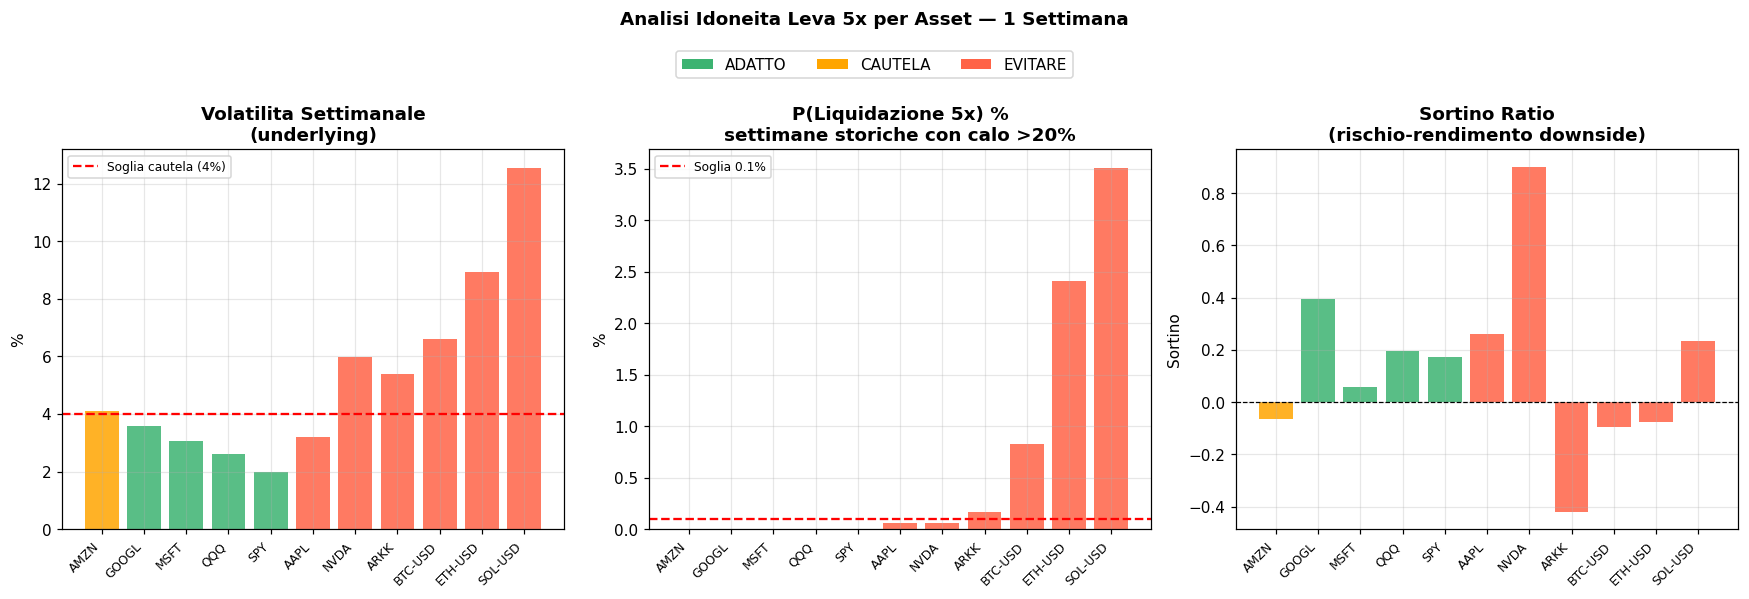

In [20]:
# Grafico comparativo: Vol settimanale, P(liquidazione), Sortino
tickers_plot = lev_df.index.tolist()
x = np.arange(len(tickers_plot))

# Colori basati sul rating (senza emoji)
color_map = {'ADATTO': 'mediumseagreen', 'CAUTELA': 'orange', 'EVITARE': 'tomato'}
clrs = [color_map.get(str(lev_df.loc[t, 'RATING']), 'gray') for t in tickers_plot]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Vol settimanale
axes[0].bar(x, lev_df['Vol sett. %'].astype(float).values, color=clrs, alpha=0.85)
axes[0].axhline(4, color='red', linestyle='--', lw=1.5, label='Soglia cautela (4%)')
axes[0].set_title('Volatilita Settimanale\n(underlying)', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].set_xticks(x); axes[0].set_xticklabels(tickers_plot, rotation=45, ha='right', fontsize=8)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# P(liquidazione)
axes[1].bar(x, lev_df['P(liq) %'].astype(float).values, color=clrs, alpha=0.85)
axes[1].axhline(0.1, color='red', linestyle='--', lw=1.5, label='Soglia 0.1%')
axes[1].set_title('P(Liquidazione 5x) %\nsettimane storiche con calo >20%', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xticks(x); axes[1].set_xticklabels(tickers_plot, rotation=45, ha='right', fontsize=8)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Sortino
axes[2].bar(x, lev_df['Sortino'].astype(float).values, color=clrs, alpha=0.85)
axes[2].axhline(0, color='black', lw=0.8, linestyle='--')
axes[2].set_title('Sortino Ratio\n(rischio-rendimento downside)', fontweight='bold')
axes[2].set_ylabel('Sortino')
axes[2].set_xticks(x); axes[2].set_xticklabels(tickers_plot, rotation=45, ha='right', fontsize=8)
axes[2].grid(alpha=0.3)

# Legenda rating
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='mediumseagreen', label='ADATTO'),
              Patch(facecolor='orange',         label='CAUTELA'),
              Patch(facecolor='tomato',          label='EVITARE')]
fig.legend(handles=legend_els, loc='upper center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 1.02))

fig.suptitle('Analisi Idoneita Leva 5x per Asset — 1 Settimana',
             fontsize=12, fontweight='bold', y=1.08)
plt.tight_layout(); plt.show()

---
## Conclusioni — Strategia Leva 5x e Raccomandazioni

### Risultati dell'analisi quantitativa

**Portafogli ottimali costruiti:**
- **GMVP** → massima conservazione del capitale, volatilità minima matematicamente garantita  
- **Black-Litterman** → pesi stabili, non estremi, incorporate le previsioni ARIMA/GARCH come views bayesiane

**Fama-French:** verifica se il rendimento del portafoglio BL è "alfa reale" o mera esposizione a fattori di rischio sistematici. Un portafoglio con α ≈ 0 non giustifica costi di gestione attiva.

---

### Strategia Leva 5x — 1 Settimana

**Regola d'oro:** con leva 5x il rischio di liquidazione si attiva ad un calo del **20%** dell'underlying in una settimana.  
Dall'analisi storica degli ultimi 5 anni:

| Asset | Peggior settimana | Liquidato? | Valutazione |
|-------|-------------------|------------|-------------|
| **SPY** | ~-10.7% | Mai | ✅ Il più sicuro |
| **QQQ** | ~-11.0% | Mai | ✅ Sicuro, tech-heavy |
| **AAPL/MSFT** | ~-12/-19% | Mai | 🟡 Rischio concentrato |
| **BTC** | ~-20.2% | **Sì** (1 volta) | 🔴 Pericoloso |
| **ETH** | ~-25.5% | **Sì** (più volte) | 🔴 Evitare |

**Indice raccomandato per leva 5x: SPY (S&P 500)**
- Volatilità settimanale ~1.9% → con 5x = ~9.6%
- 504 settimane analizzate: **zero liquidazioni**
- Sortino più alto tra gli ETF azionari

**Setup operativo settimana corrente:**
```
Segnale ARIMA SPY 5 giorni: verifica nella cella 3
Entry:  Apertura lunedì, long SPY 5x (futures/CFD/ETP SPXL)
Target: +3% sul sottostante = +15% sulla posizione
Stop:   -4% sul sottostante = -20% sulla posizione (soglia liquidazione)
Size:   Kelly fraction / 5 (ridotta per prudenza)
```

**Disclaimer:** Questa analisi è a scopo educativo e non costituisce consulenza finanziaria. La leva amplifica le perdite quanto i guadagni. Dati storici non garantiscono performance future.